# Brazil E-Commerce — Products Analysis

Analysis of the **Olist `olist_products_dataset.csv`** file, joined to
`product_category_name_translation.csv` for English category names.

Columns:
- `product_id` — unique product identifier
- `product_category_name` — category (Portuguese)
- `product_name_lenght` — character length of the product name
- `product_description_lenght` — character length of the description
- `product_photos_qty` — number of published photos
- `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm` — physical dims

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

## 1. Load the data

In [2]:
products = pd.read_csv("Data/olist_products_dataset.csv")
trans = pd.read_csv("Data/product_category_name_translation.csv")

products = products.merge(trans, on="product_category_name", how="left")
products["category"] = products["product_category_name_english"].fillna(
    products["product_category_name"]
)
print(f"Shape: {products.shape[0]:,} rows x {products.shape[1]} columns")
products.head()

Shape: 32,951 rows x 11 columns


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,category
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares,housewares


In [3]:
products.info()
products.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32951 non-null  str    
 1   product_category_name          32341 non-null  str    
 2   product_name_lenght            32341 non-null  float64
 3   product_description_lenght     32341 non-null  float64
 4   product_photos_qty             32341 non-null  float64
 5   product_weight_g               32949 non-null  float64
 6   product_length_cm              32949 non-null  float64
 7   product_height_cm              32949 non-null  float64
 8   product_width_cm               32949 non-null  float64
 9   product_category_name_english  32328 non-null  str    
 10  category                       32341 non-null  str    
dtypes: float64(7), str(4)
memory usage: 2.8 MB


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,category
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000,32328,32341
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71,73
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bed_bath_table,bed_bath_table
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3029,3029
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728,NaN,NaN
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047,NaN,NaN
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,NaN,NaN
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000,NaN,NaN
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000,NaN,NaN
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000,NaN,NaN


## 2. Data quality checks

In [4]:
print("Missing values per column:")
print(products.isna().sum())

print(f"\nFully duplicated rows: {products.duplicated().sum():,}")
print(f"Distinct products:   {products['product_id'].nunique():,}")
print(f"Distinct categories: {products['category'].nunique():,}")

Missing values per column:
product_id                         0
product_category_name            610
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english    623
category                         610
dtype: int64

Fully duplicated rows: 0
Distinct products:   32,951
Distinct categories: 73


## 3. Products per category

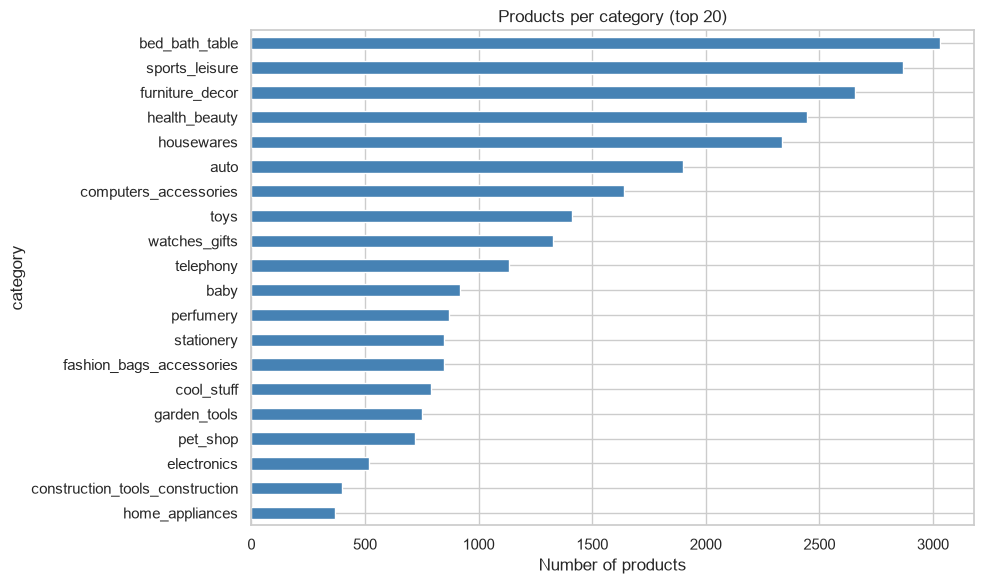

In [5]:
by_cat = products["category"].value_counts()
ax = by_cat.head(20).plot(kind="barh", color="steelblue")
ax.invert_yaxis()
ax.set_title("Products per category (top 20)")
ax.set_xlabel("Number of products")
plt.tight_layout()
plt.show()

## 4. Physical dimensions and weight

       product_weight_g  product_length_cm  product_height_cm  \
count      32949.000000       32949.000000       32949.000000   
mean        2276.472488          30.815078          16.937661   
std         4282.038731          16.914458          13.637554   
min            0.000000           7.000000           2.000000   
25%          300.000000          18.000000           8.000000   
50%          700.000000          25.000000          13.000000   
75%         1900.000000          38.000000          21.000000   
max        40425.000000         105.000000         105.000000   

       product_width_cm  
count      32949.000000  
mean          23.196728  
std           12.079047  
min            6.000000  
25%           15.000000  
50%           20.000000  
75%           30.000000  
max          118.000000  


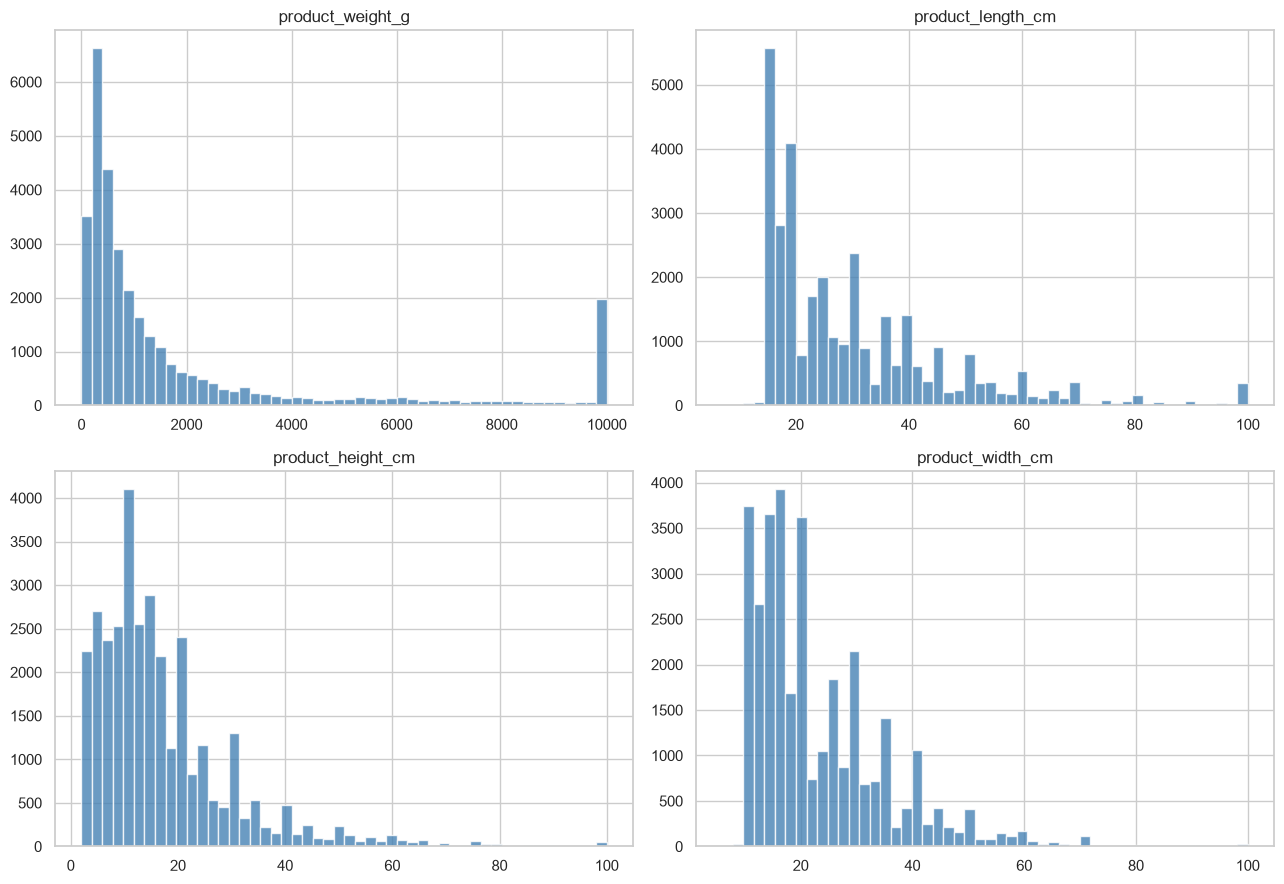

In [6]:
dims = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
print(products[dims].describe())

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
clips = {"product_weight_g": 10000, "product_length_cm": 100,
         "product_height_cm": 100, "product_width_cm": 100}
for ax, col in zip(axes.ravel(), dims):
    ax.hist(products[col].clip(0, clips[col]), bins=50, color="steelblue", alpha=0.8)
    ax.set_title(col)
plt.tight_layout()
plt.show()

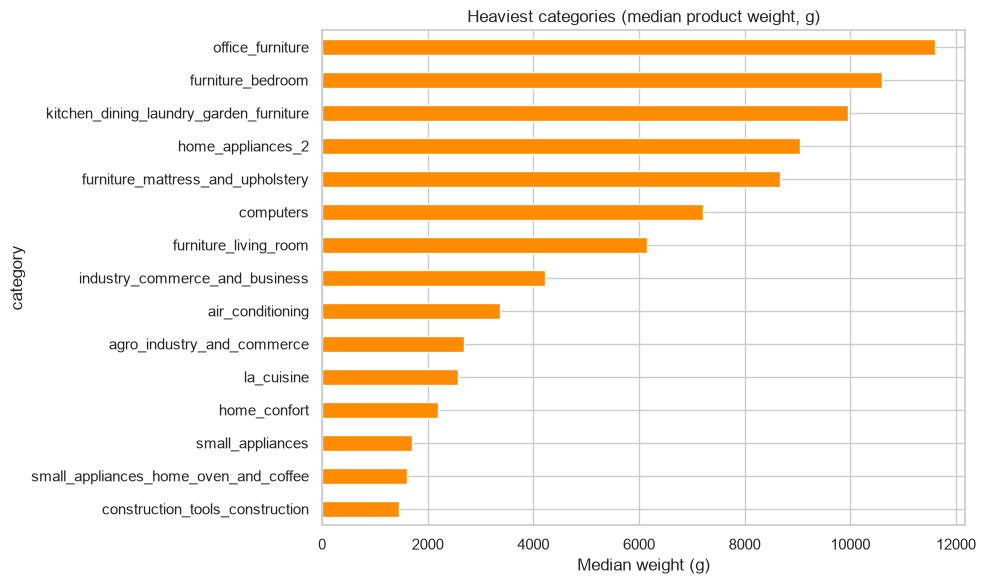

In [7]:
products["volume_cm3"] = (
    products["product_length_cm"] * products["product_height_cm"] * products["product_width_cm"]
)
heaviest = (
    products.groupby("category")["product_weight_g"].median().sort_values(ascending=False).head(15)
)
ax = heaviest.plot(kind="barh", color="darkorange")
ax.invert_yaxis()
ax.set_title("Heaviest categories (median product weight, g)")
ax.set_xlabel("Median weight (g)")
plt.tight_layout()
plt.show()

## 5. Listing richness — photos & description length

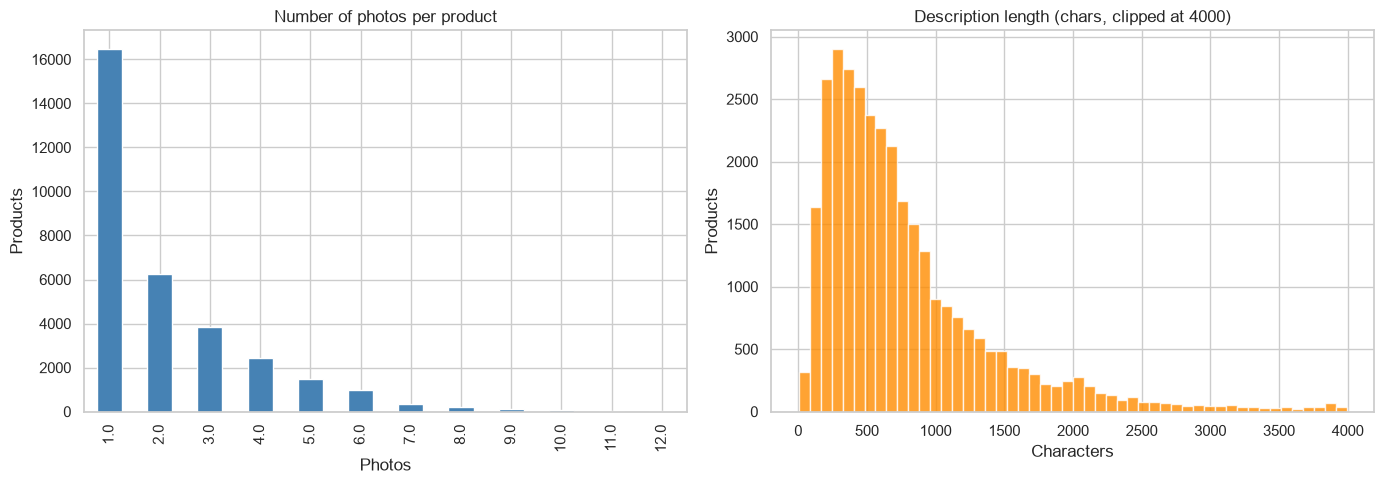

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
products["product_photos_qty"].value_counts().sort_index().head(12).plot(
    kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Number of photos per product")
axes[0].set_xlabel("Photos")
axes[0].set_ylabel("Products")

axes[1].hist(products["product_description_lenght"].dropna().clip(0, 4000),
             bins=50, color="darkorange", alpha=0.8)
axes[1].set_title("Description length (chars, clipped at 4000)")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Products")
plt.tight_layout()
plt.show()

## 6. Key takeaways

_Fill in after running the cells above. Typical findings for this dataset:_

- The catalog spans ~70 categories; bed/bath, health/beauty, sports and furniture lead by product count.
- Weight and dimensions are highly right-skewed; furniture/appliances categories are heaviest.
- A small number of dimension/weight rows are missing and should be imputed before shipping-cost modeling.
- Most listings have 1–3 photos and a moderate description length.